Regression and Classification Algorithms



Simple Linear Regression

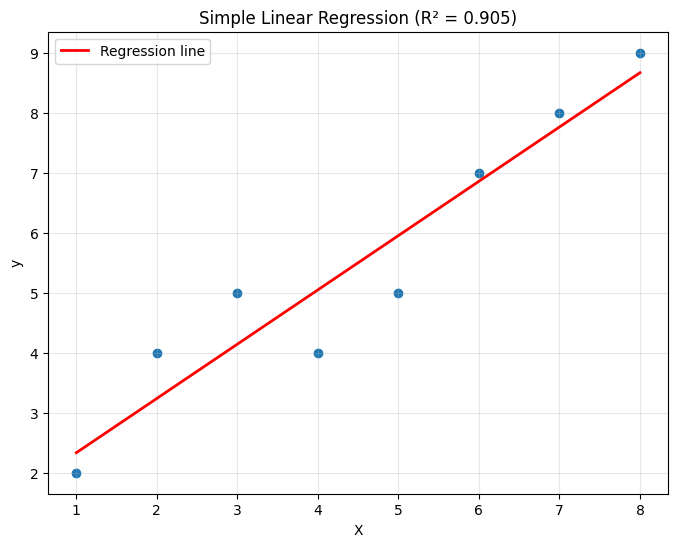

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
X = np.array([1, 2, 3, 4, 5, 6, 7, 8]).reshape(-1, 1)
y = np.array([2, 4, 5, 4, 5, 7, 8, 9])
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X, y) #color='steelblue', label='Actual data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression line')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Simple Linear Regression (R² = {model.score(X, y):.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Multiple Linear Regression

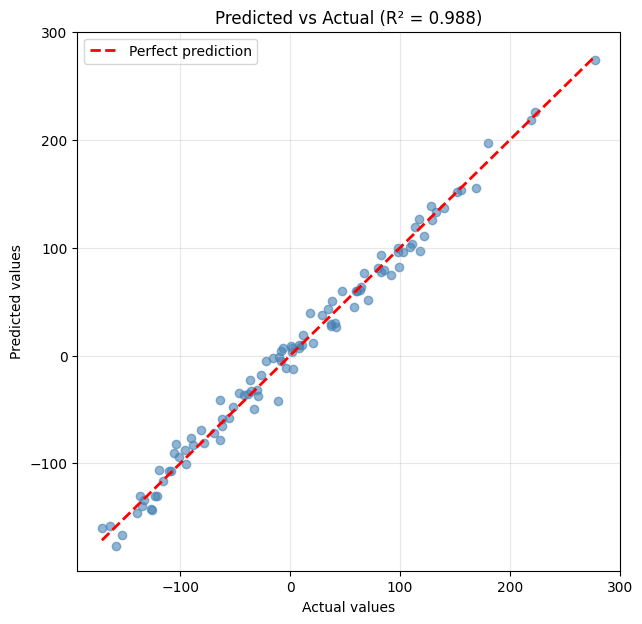

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

# Example data with multiple features
X, y = make_regression(n_samples=100, n_features=4, noise=10, random_state=42)

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(7, 7))
plt.scatter(y, y_pred, alpha=0.6, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title(f'Predicted vs Actual (R² = {model.score(X, y):.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Polynomial Regression

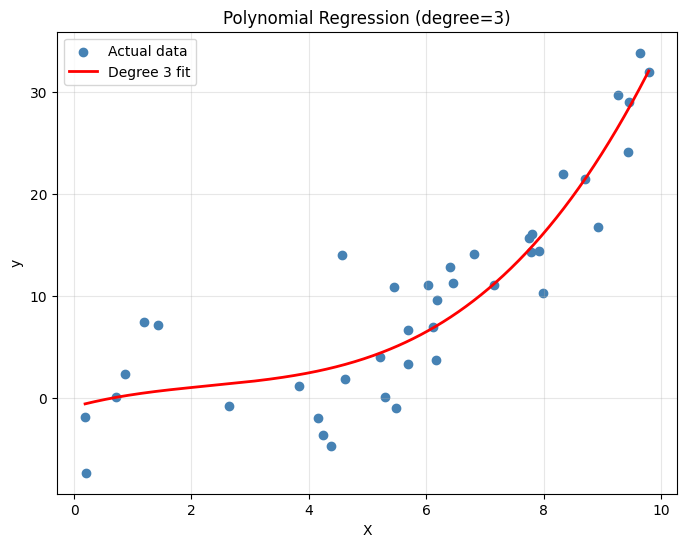

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
np.random.seed(0)
X = np.sort(np.random.rand(40, 1) * 10, axis=0)
y = 0.5 * X.ravel()**2 - 2*X.ravel() + 3 + np.random.randn(40) * 5
degree = 3
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X, y)
X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_smooth = model.predict(X_smooth)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='steelblue', label='Actual data')
plt.plot(X_smooth, y_smooth, color='red', linewidth=2, label=f'Degree {degree} fit')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Polynomial Regression (degree={degree})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Decision Tree

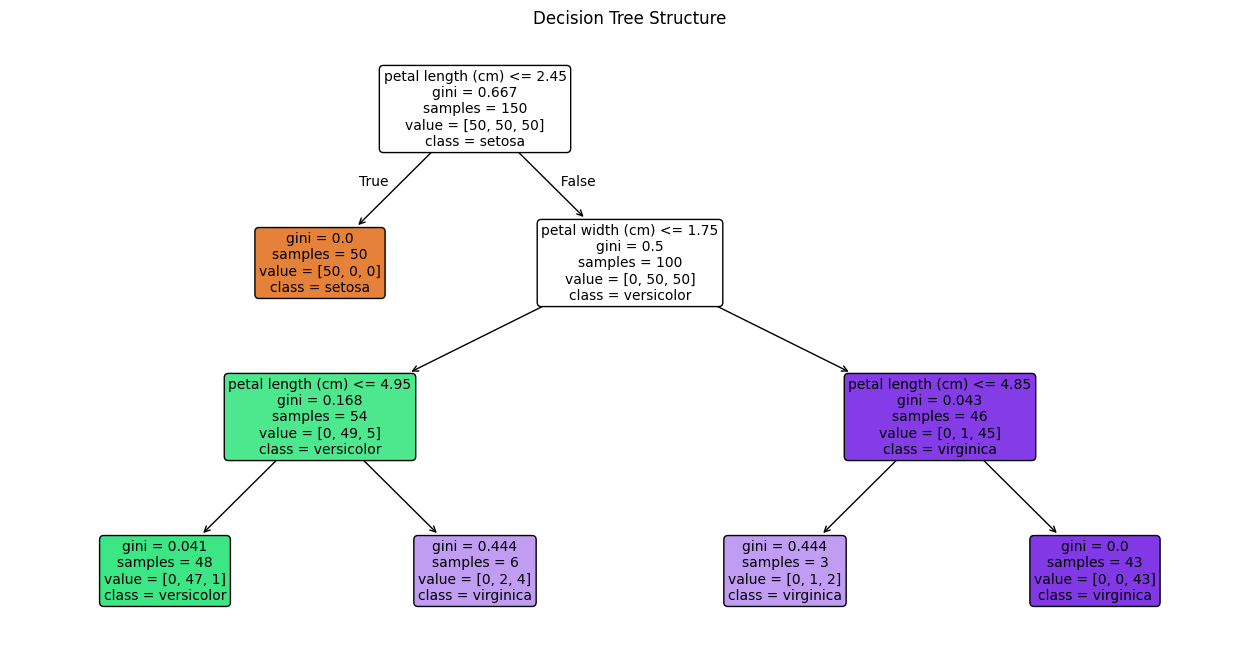

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris

data = load_iris()
X, y = data.data, data.target

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

plt.figure(figsize=(16, 8))
plot_tree(clf, feature_names=data.feature_names, class_names=data.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Structure')
plt.show()

Random Forest

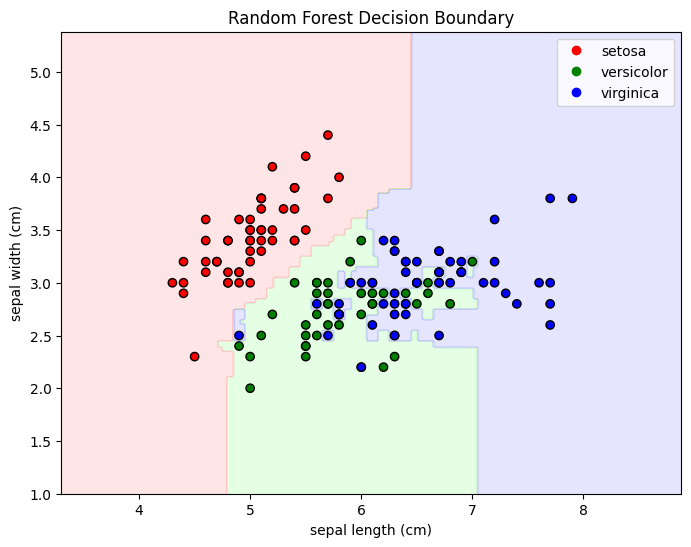

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

data = load_iris()
X, y = data.data[:, :2], data.target  # 2 features for visualization

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = rf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=ListedColormap(['red', 'green', 'blue']))
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title('Random Forest Decision Boundary')
plt.legend(handles=scatter.legend_elements()[0], labels=list(data.target_names))
plt.show()

Support Vector Machine(SVM)

Accuracy: 1.0


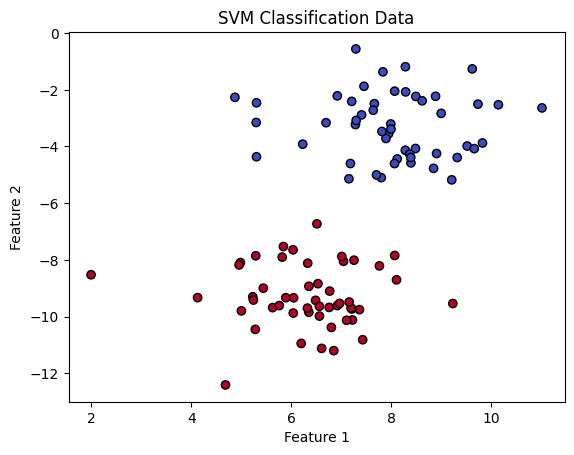

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title('SVM Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

KNN

Accuracy: 1.0


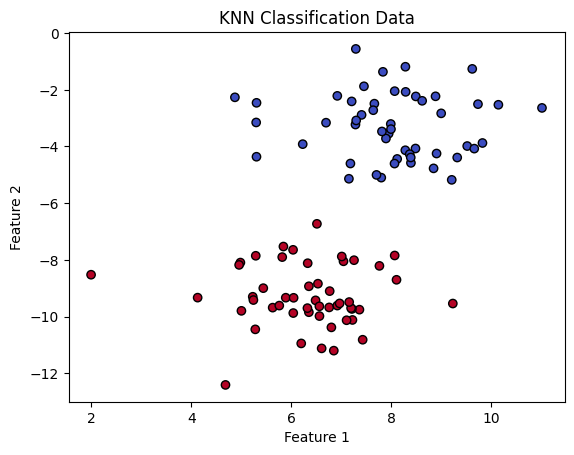

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title('KNN Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Logistic Regression

Accuracy: 1.0


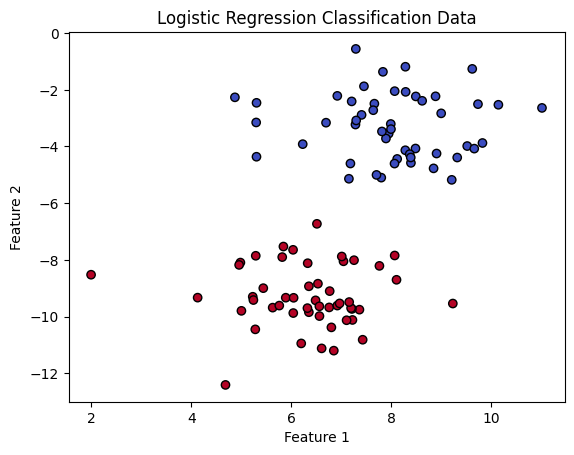

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title('Logistic Regression Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Naive Bayes Classification

Accuracy: 1.0


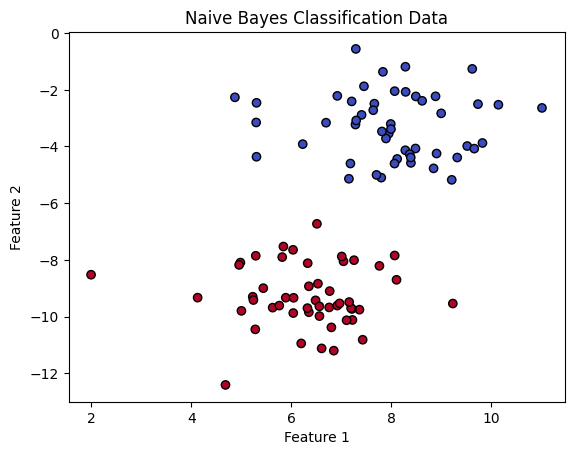

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title('Naive Bayes Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

write a program on detecting weather the eamil is spam or not

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

emails = [
    "Win a free prize now, click here",
    "Meeting scheduled for tomorrow at 10am",
    "You have won $1000 cash, claim now",
    "Please review the report by Friday",
    "Get cheap loans instantly, act now",
    "Can we reschedule our call?"
]
labels = [1, 0, 1, 0, 1, 0]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

model = MultinomialNB()
model.fit(X, labels)

new_email = ["Claim your free prize now"]
new_email_vec = vectorizer.transform(new_email)
prediction = model.predict(new_email_vec)

print("SPAM" if prediction[0] == 1 else "NOT SPAM")

SPAM
